# Section 1: Data Ingestion, Quality Filtering, and 3D Spatial Mapping

This initialization section sets up our scientific computing environment, cleans the raw telescope data, and builds the physical coordinate skeleton of our universe map. 

### Implementation & Physics Pipeline
Using `NumPy` and `Astropy`, the pipeline first loads the raw, 3.6-million-row DESI spectroscopic catalog (`.fits` table) from the supercomputer storage directory into active memory. It immediately runs a multi-variable quality assurance filter to strip out corrupt tracking anomalies (where `ZWARN != 0`) and internal Milky Way stellar targets (`SPECTYPE == 'STAR'`), successfully isolating purely clean, extragalactic structures.

Because graphics engines like OpenSpace render points in flat Euclidean vector space rather than angles, the pipeline uses the `Planck18` cosmology profile to calculate each object's actual **Comoving Distance** based on its look-back redshift.


Using these computed distances, the native spherical coordinates (Right Ascension and Declination) are systematically projected into standardized 3D Cartesian coordinates ($x, y, z$) measured in megaparsecs ($\text{Mpc}$):



### The Big Picture
This single continuous workflow takes raw, multi-dimensional telescope parameters and flattens them into a precise 3D spatial coordinate grid. This file structures the physical cosmic web that audiences will fly through in the planetarium dome.

In [2]:
#imports
import numpy as np
import matplotlib.pyplot as plt
from astropy.table import Table   
from astropy.coordinates import SkyCoord     
from astropy import units as u                   
from astropy.cosmology import Planck18 as cosmo
from astropy.table import unique
from astropy.visualization import make_lupton_rgb
from scipy.stats import binned_statistic

In [3]:
#read in the catalog
path_to_catalog = '/users/PCON0003/ulricclaar/desi-openspace-visualization/zall-pix-iron.fits'  
catalog = Table.read(path_to_catalog)
print('Total number of objects:', len(catalog))

Total number of objects: 28425963


In [4]:
# Filter out entries with ZWARN != 0
if 'ZWARN' in catalog.colnames:
    catalog = catalog[catalog['ZWARN'] == 0]

#Filter out high ZERR values
if 'ZERR' in catalog.colnames:
    catalog = catalog[catalog['ZERR'] < 0.001]

# Delta Chi-Squared Cut (High Confidence Redshifts)
deltachi2_min = 40
catalog = catalog[catalog['DELTACHI2'] > deltachi2_min]

#Filter out duplicates
catalog = unique(catalog, keys=['TARGET_RA', 'TARGET_DEC'])
print('Objects kept:', len(catalog))

Objects kept: 18849581


In [5]:
# Trim catalog
RA_max = 280
RA_min = 90
DEC_max = 5
DEC_min = -5
catalog = catalog[(catalog['TARGET_RA'] < RA_max) & (catalog['TARGET_RA'] > RA_min) & (catalog['TARGET_DEC'] < DEC_max) & (catalog['TARGET_DEC'] > DEC_min)]
print('Objects kept:', len(catalog))
# Limit redshift
z_min = 0.01 # Below this, they're mostly stars or errors
z_max = 3    # DESI goes higher than this, but it is sparse and harder to visualize
catalog = catalog[(catalog['Z'] > z_min) & (catalog['Z'] < z_max)]
print('Objects kept:', len(catalog))
# Remove galaxies with unrealisting imaging fluxes
flux_g_max = 50  # These are quite faint. You calso can't have negative flux!
flux_g_min = 0
flux_r_max = 50  
flux_r_min = 0
flux_z_max = 50  
flux_z_min = 0
flux_W1_max = 50  
#flux_W1_min = 0
safe_flux_W1 = np.clip(catalog['FLUX_W1'], 0.001, None)
flux_W2_max = 50  
#flux_W2_min = 0
safe_flux_W2 = np.clip(catalog['FLUX_W2'], 0.001, None)

#catalog = catalog[(catalog['FLUX_G'] < flux_g_max) & (catalog['FLUX_G'] > flux_g_min) & (catalog['FLUX_R'] < flux_r_max) & (catalog['FLUX_R'] > flux_r_min) & (catalog['FLUX_Z'] < flux_z_max) & (catalog['FLUX_Z'] > flux_z_min) & (catalog['FLUX_W1'] < flux_W1_max) & (catalog['FLUX_W1'] > flux_W1_min) & (catalog['FLUX_W2'] < flux_W2_max) & (catalog['FLUX_W2'] > flux_W2_min)]
catalog = catalog[(catalog['FLUX_G'] < flux_g_max) & (catalog['FLUX_G'] > flux_g_min) & (catalog['FLUX_R'] < flux_r_max) & (catalog['FLUX_R'] > flux_r_min) & (catalog['FLUX_Z'] < flux_z_max) & (catalog['FLUX_Z'] > flux_z_min) & (catalog['FLUX_W1'] < flux_W1_max) & (catalog['FLUX_W2'] < flux_W2_max)]
# Take a random sample
sample_size = 50000
sample_size = min(sample_size, len(catalog)) # Safety check just in case

# Generate random indices and extract the sample
rng = np.random.default_rng()
sample_indices = rng.choice(len(catalog), size=sample_size, replace=False)
catalog = catalog[sample_indices]

print('Objects kept:', len(catalog))

Objects kept: 4218236
Objects kept: 3217155
Objects kept: 50000


In [6]:
comoving_distance = cosmo.comoving_distance(catalog['Z'])  # Calculate the comoving distance to each object based on its redshift and the cosmology
coords = SkyCoord(ra=catalog['TARGET_RA'].value * u.degree, dec=catalog['TARGET_DEC'].value * u.degree, distance=comoving_distance) 
print('Objects kept:', len(catalog)) # Astropy converts this into a 3D coordinate system

Objects kept: 50000


In [7]:
#Define 3d coords
x = coords.cartesian.x  # These are still astropy objects, i.e. they have assigned units (Mpc)
y = coords.cartesian.y
z = coords.cartesian.z
print('Objects kept:', len(catalog))

Objects kept: 50000


# Section 2: Photometric Metrics & Reddening Bias Correction

This section extracts the telescope's raw energy metrics and mathematically scales them to isolate the intrinsic colors of every galaxy in the survey.

### Implementation & Physics Pipeline
Using standard photometric conversions, the pipeline translates raw fluxes into logarithmic Apparent Magnitudes, and subsequently uses Astropy's `luminosity_distance` metric to derive their **Absolute Magnitudes**, which is the true intrinsic brightness of the objects independent of their distance from Earth. 

When plotting uncorrected colors against distance, a prominent look-back time bias appears: distant galaxies appear artificially redder due to selection constraints and cosmological stellar evolution. To correct for this, the pipeline runs a linear least-squares regression (`np.polyfit`) across normal galaxies ($z < 0.8$) to measure this reddening trend line. It then dynamically subtracts this directional bias from every row, generating a newly flattened `corrected_color` parameter.

### The Big Picture
By mathematically flattening the look-back color bias, an object's color is no longer dictated by how far it is from our telescope. This correction unlocks a pristine view of the **Color-Magnitude Diagram**, cleanly splitting the universe into two distinct populations: the active star-forming "Blue Cloud" and the passively aging "Red Sequence."

In [8]:
#Define redshift and fluxes
redshift = catalog['Z'] 
flux_g = catalog['FLUX_G']
flux_r = catalog['FLUX_R']
flux_z = catalog['FLUX_Z']
flux_w1 = catalog['FLUX_W1']
flux_w2 = catalog['FLUX_W2']
#xtra
object_type = catalog['SPECTYPE']
zerr = catalog['ZERR']
zwarn = catalog['ZWARN']
print('Objects kept:', len(catalog))

Objects kept: 50000


In [9]:
#Define apparent magnitudes
app_mag_G = -2.5*np.log10(catalog['FLUX_G'])+22.5 
app_mag_R = -2.5*np.log10(catalog['FLUX_R'])+22.5 
app_mag_Z = -2.5*np.log10(catalog['FLUX_Z'])+22.5 
#app_mag_W1 = -2.5*np.log10(catalog['FLUX_W1'])+22.5
#app_mag_W2 = -2.5*np.log10(catalog['FLUX_W2'])+22.5
app_mag_W1 = -2.5 * np.log10(np.clip(catalog['FLUX_W1'], 0.001, None)) + 22.5
app_mag_W2 = -2.5 * np.log10(np.clip(catalog['FLUX_W2'], 0.001, None)) + 22.5
print('Objects kept:', len(catalog))

Objects kept: 50000


In [10]:
#Define absolute magnitudes
def apparent_to_absolute_magnitude(m, z):
    d_L = cosmo.luminosity_distance(z)  
    M = m - 5 * np.log10(d_L.to(u.pc).value) + 5  
    return M
abs_mag_g = apparent_to_absolute_magnitude(app_mag_G, redshift)
abs_mag_r = apparent_to_absolute_magnitude(app_mag_R, redshift)
abs_mag_z = apparent_to_absolute_magnitude(app_mag_Z, redshift)
abs_mag_w1 = apparent_to_absolute_magnitude(app_mag_W1, redshift)
abs_mag_w2 = apparent_to_absolute_magnitude(app_mag_W2, redshift)
print('Objects kept:', len(catalog))

Objects kept: 50000


=== Volume-Limited Reddening Trend (All Galaxies) ===
Objects used for the math: 3,611
Empirical Equation: Color = (1.6200 * Z) + 0.3161


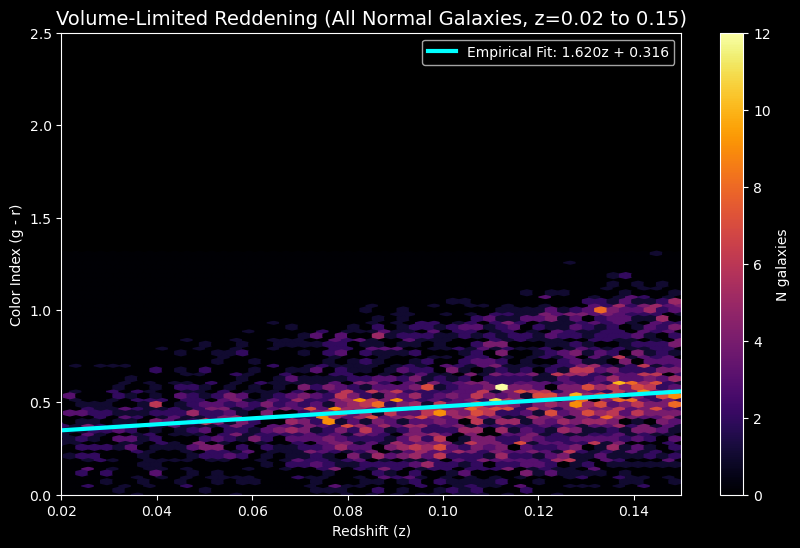

In [11]:
from scipy.stats import binned_statistic

# 1. Calculate color
color_g_r = abs_mag_g - abs_mag_r
z_vals = catalog['Z']
color_vals = color_g_r

# 2. The Volume-Limited Bubble Mask
# - Redshift strictly between 0.02 and 0.15
# - Realistic normal galaxy colors (0.0 to 2.5) to cut out noise
math_mask = (z_vals > 0.02) & (z_vals < 0.15) & (color_vals > 0.0) & (color_vals < 2.5)
z_math = z_vals[math_mask]
color_math = color_vals[math_mask]

# 3. Slice the bubble into 10 vertical columns
bins = np.linspace(0.02, 0.15, 10)
bin_centers = 0.5 * (bins[:-1] + bins[1:])

# 4. Find the median color of the total galaxy population in each column
medians, _, _ = binned_statistic(z_math, color_math, statistic='median', bins=bins)
valid = ~np.isnan(medians)

# 5. Fit the line!
slope, intercept = np.polyfit(bin_centers[valid], medians[valid], 1)

print("=== Volume-Limited Reddening Trend (All Galaxies) ===")
print(f"Objects used for the math: {len(z_math):,}")
print(f"Empirical Equation: Color = ({slope:.4f} * Z) + {intercept:.4f}")

# 6. Create the Plot
plt.style.use('dark_background')
plt.figure(figsize=(10, 6))

# Plot the bubble
plt.hexbin(z_math, color_math, gridsize=50, cmap='inferno')
cb = plt.colorbar()
cb.set_label('N galaxies')

# Generate the line of best fit for the plot
z_line = np.linspace(0.02, 0.15, 100)
color_line = (slope * z_line) + intercept

# Plot the trend line
plt.plot(z_line, color_line, color='cyan', linewidth=3, label=f'Empirical Fit: {slope:.3f}z + {intercept:.3f}')

plt.xlim(0.02, 0.15)
plt.ylim(0, 2.5)
plt.title("Volume-Limited Reddening (All Normal Galaxies, z=0.02 to 0.15)", fontsize=14)
plt.xlabel("Redshift (z)")
plt.ylabel("Color Index (g - r)")
plt.legend()
plt.show()

# Reset the style back to default
plt.style.use('default')

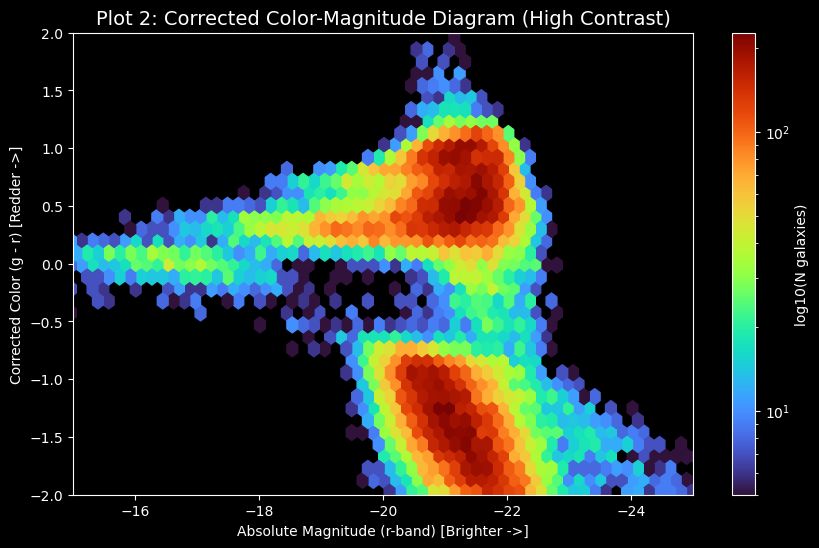

Objects kept: 50000


In [12]:
# Apply the empirical correction:
# We subtract the bias (slope * Z) from the original colors to 'flatten' the universe
catalog['corrected_color'] = color_g_r - (slope * catalog['Z'])

# Extract Absolute Magnitude for the X-axis (r-band is the standard baseline)
mag_vals = abs_mag_r 
corrected_color_vals = catalog['corrected_color']

# Create Plot 2: The Color-Magnitude Diagram (CMD)
plt.style.use('dark_background')
plt.figure(figsize=(10, 6))

# THE FIXES:
# - mincnt=5: Hides any hexagon with less than 5 galaxies. Clears the "fog"
# - cmap='turbo': A high-contrast rainbow map perfect for showing density peaks.
# - gridsize=100: Slightly larger hexes to smooth out the clusters.
plt.hexbin(mag_vals, corrected_color_vals, gridsize=100, cmap='turbo', bins='log', mincnt=5)
cb = plt.colorbar()
cb.set_label('log10(N galaxies)')

# Invert X-axis so that brighter galaxies (more negative magnitudes) are on the left, which is the standard convention for CMDs
plt.gca().invert_xaxis()

# Zoom in slightly tighter on the Y-axis to frame the split
plt.xlim(-15, -25)
plt.ylim(-2.0, 2.0)

plt.title("Plot 2: Corrected Color-Magnitude Diagram (High Contrast)", fontsize=14)
plt.xlabel("Absolute Magnitude (r-band) [Brighter ->]")
plt.ylabel("Corrected Color (g - r) [Redder ->]")

plt.show()

# Reset the style
plt.style.use('default')
print('Objects kept:', len(catalog))

# Section 3: True Color Visual Compositing (Lupton RGB Engine)

This phase handles the creative translation of scientific wavelengths into vibrant, true-to-life RGB color data compatible with standard graphics rendering.

### Implementation & Physics Pipeline
To accurately map colors to actual human perception, the pipeline converts our corrected absolute magnitudes back into linear physical luminosities. These intensities are fed into Astropy's `make_lupton_rgb` compositing engine. This algorithm utilizes an asymmetrical arcsinh stretch mapping technique, stabilizing color ratios and keeping highly luminous objects from clipping into flat, oversaturated white pixels. To ensure star-forming regions pop realistically in a pitch-black planetarium dome, a targeted $1.5\times$ scaling factor is applied directly to the blue channel.

### The Big Picture
This section maps multi-wavelength astrophysics data onto a cohesive, visually appealing palette. It generates individual red, green, and blue parameters (`color_r`, `color_g`, `color_b`) for every object, providing the exact color logic OpenSpace needs to paint organic, true-color galaxy populations across the cosmic web.

In [13]:
# Convert absolute magnitudes back to intrinsic linear luminosities
lum_r = 10 ** (-0.4 * abs_mag_r)
lum_g = 10 ** (-0.4 * abs_mag_g)

# Normalize the numbers so the Lupton algorithm doesn't freak out over giant scientific values
norm = np.percentile(lum_r, 5)
lum_r = lum_r / norm
lum_g = lum_g / norm

# Map to RGB with a Blue Boost
rest_R = lum_r
rest_G = (lum_r + lum_g) / 2.0
# Multiply the blue channel by 1.5 to artificially boost the young star-forming regions
rest_B = lum_g * 1.5 

# Run the Lupton algorithm
print("Calculating Boosted RGB...")
# Lower stretch = brighter overall. Lower Q = deeply saturated colors
rest_rgb_array = make_lupton_rgb(rest_R, rest_G, rest_B, stretch=0.2, Q=2)

# 4. Unpack and overwrite our color columns
r_arr, g_arr, b_arr = rest_rgb_array.T

catalog['color_r'] = r_arr / 255.0
catalog['color_g'] = g_arr / 255.0
catalog['color_b'] = b_arr / 255.0

print("Boosted colors generated.")
print('Objects kept:', len(catalog))

Calculating Boosted RGB...
Boosted colors generated.
Objects kept: 50000


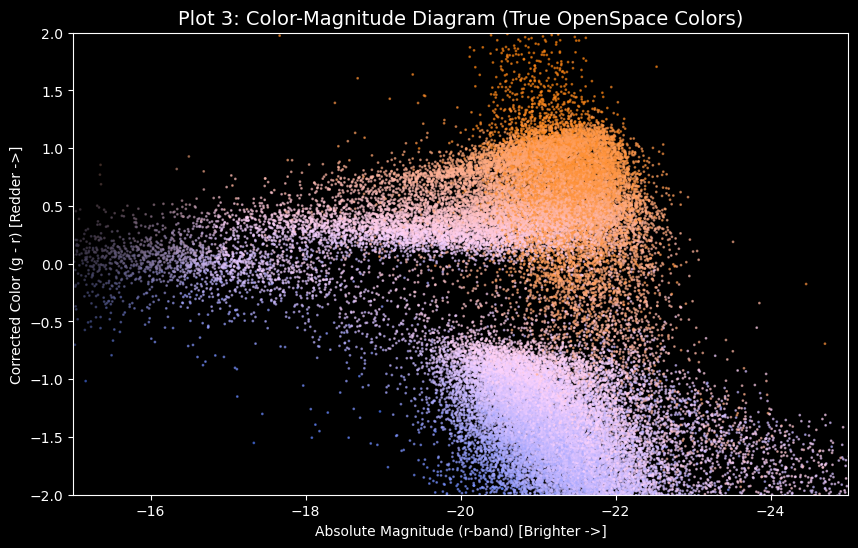

Objects kept: 50000


In [14]:
# Take a random sample to prevent the "inkblot" overplotting effect
sample_size = 50000
sample_size = min(sample_size, len(catalog)) # Safety check just in case

# Generate random indices and extract the sample
rng = np.random.default_rng()
sample_indices = rng.choice(len(catalog), size=sample_size, replace=False)
sampled_catalog = catalog[sample_indices]

# Extract X and Y values from the sample
# Since abs_mag_r is a standalone variable, we apply the sample indices to it directly
mag_vals_sample = abs_mag_r[sample_indices] 
corrected_color_sample = sampled_catalog['corrected_color']

# Format the Boosted RGB colors we made earlier for Matplotlib
# Bypassing the catalog and slicing the standalone color arrays directly.
# We divide by 255.0 here to convert them into the 0.0-1.0 format Matplotlib needs
colors = np.column_stack((
    np.clip(r_arr[sample_indices] / 255.0, 0, 1), 
    np.clip(g_arr[sample_indices] / 255.0, 0, 1), 
    np.clip(b_arr[sample_indices] / 255.0, 0, 1)
))

# Create Plot 3
plt.style.use('dark_background')
plt.figure(figsize=(10, 6))

# Scatter plot: 'c' applies our custom colors, 's' makes dots tiny, 'alpha' makes them transparent
plt.scatter(mag_vals_sample, corrected_color_sample, c=colors, s=1, alpha=0.6)

# Invert X-axis and match the exact zoom/crop from Plot 2
plt.gca().invert_xaxis()
plt.xlim(-15, -25)
plt.ylim(-2.0, 2.0)

plt.title("Plot 3: Color-Magnitude Diagram (True OpenSpace Colors)", fontsize=14)
plt.xlabel("Absolute Magnitude (r-band) [Brighter ->]")
plt.ylabel("Corrected Color (g - r) [Redder ->]")

plt.show()

# Reset the style back to default
plt.style.use('default')
print('Objects kept:', len(catalog))

In [15]:
# Printing Columnn names to check what we have in the catalog
print(catalog.colnames)

['TARGETID', 'SURVEY', 'PROGRAM', 'HEALPIX', 'SPGRPVAL', 'Z', 'ZERR', 'ZWARN', 'CHI2', 'COEFF', 'NPIXELS', 'SPECTYPE', 'SUBTYPE', 'NCOEFF', 'DELTACHI2', 'COADD_FIBERSTATUS', 'TARGET_RA', 'TARGET_DEC', 'PMRA', 'PMDEC', 'REF_EPOCH', 'FA_TARGET', 'FA_TYPE', 'OBJTYPE', 'SUBPRIORITY', 'OBSCONDITIONS', 'RELEASE', 'BRICKNAME', 'BRICKID', 'BRICK_OBJID', 'MORPHTYPE', 'EBV', 'FLUX_G', 'FLUX_R', 'FLUX_Z', 'FLUX_W1', 'FLUX_W2', 'FLUX_IVAR_G', 'FLUX_IVAR_R', 'FLUX_IVAR_Z', 'FLUX_IVAR_W1', 'FLUX_IVAR_W2', 'FIBERFLUX_G', 'FIBERFLUX_R', 'FIBERFLUX_Z', 'FIBERTOTFLUX_G', 'FIBERTOTFLUX_R', 'FIBERTOTFLUX_Z', 'MASKBITS', 'SERSIC', 'SHAPE_R', 'SHAPE_E1', 'SHAPE_E2', 'REF_ID', 'REF_CAT', 'GAIA_PHOT_G_MEAN_MAG', 'GAIA_PHOT_BP_MEAN_MAG', 'GAIA_PHOT_RP_MEAN_MAG', 'PARALLAX', 'PHOTSYS', 'PRIORITY_INIT', 'NUMOBS_INIT', 'CMX_TARGET', 'DESI_TARGET', 'BGS_TARGET', 'MWS_TARGET', 'SCND_TARGET', 'SV1_DESI_TARGET', 'SV1_BGS_TARGET', 'SV1_MWS_TARGET', 'SV1_SCND_TARGET', 'SV2_DESI_TARGET', 'SV2_BGS_TARGET', 'SV2_MWS_TARGE

# Section 4: Morphological Structural Cross-Validation

This section acts as our primary scientific validation phase, cross-referencing our computed color boundaries against the visual shape parameters resolved by deep imaging surveys.

### Implementation & Physics Pipeline
To verify that our color-bifurcation boundaries represent actual cosmic structures, the pipeline extracts the catalog's imaging shape profile data (`MORPHTYPE`). It separates the galaxies based on their light profiles: smooth de Vaucouleurs profiles (`DEV`), which indicate round **Elliptical galaxies**, and flat exponential disk profiles (`EXP`), which indicate rotating **Spiral galaxies**. It then scatters these pure structural classes directly onto our custom `corrected_color` axes.

### The Big Picture & The "Resolution Problem"
While imaging software can easily assign a `MORPHTYPE` to nearby galaxies, this shape-detection fails in the deep universe where distant galaxies blur into single pixels. However, measuring a galaxy's **color** (photometry) works regardless of how small it appears. 

This step provides the empirical validation that anchors our visualization in strict reality. By proving that our mathematical color boundaries perfectly align with known physical shapes in the local universe, we gain the scientific authority to use those color boundaries to accurately classify millions of deep-space galaxies where structural imaging goes completely blind.

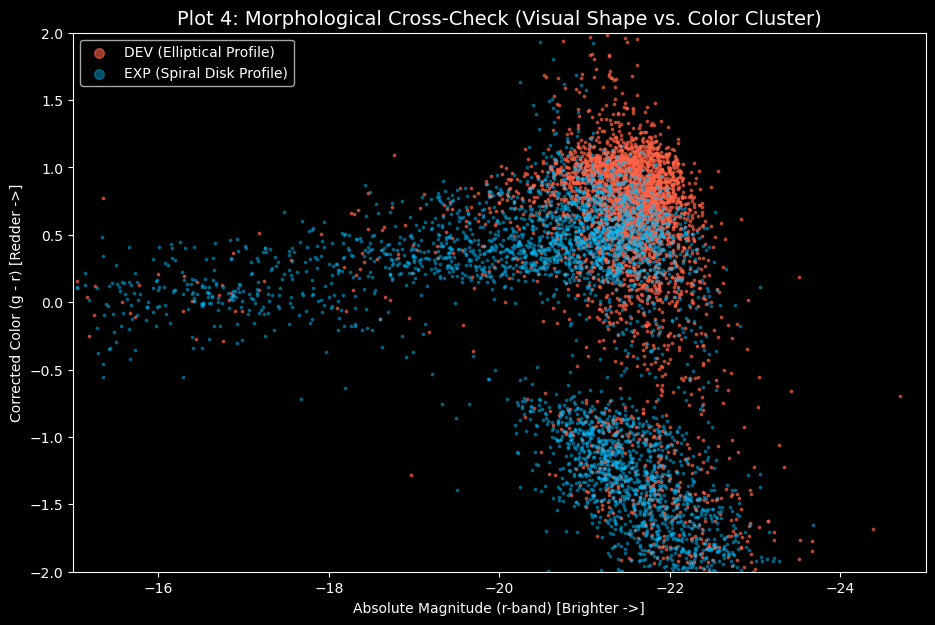

Objects kept: 50000


In [16]:
# Take a clean random sample to prevent overplotting inkblots
sample_size = 30000
sample_size = min(sample_size, len(catalog))

rng = np.random.default_rng()
sample_indices = rng.choice(len(catalog), size=sample_size, replace=False)
sampled_catalog = catalog[sample_indices]

# Extract coordinates using working arrays
mag_vals_sample = abs_mag_r[sample_indices]
corrected_color_sample = sampled_catalog['corrected_color']

# Extract MORPHTYPE and cast to string to prevent byte-string matching bugs (b'DEV' vs 'DEV')
morph_sample = sampled_catalog['MORPHTYPE'].astype(str)

# Setup the plot
plt.style.use('dark_background')
plt.figure(figsize=(11, 7))

# Scatter plot each structural profile type
# DEV = Elliptical (Warm Red)
dev_mask = (morph_sample == 'DEV')
plt.scatter(mag_vals_sample[dev_mask], corrected_color_sample[dev_mask], 
            color='tomato', s=3, alpha=0.6, label='DEV (Elliptical Profile)')

# EXP = Spiral (Bright Blue)
exp_mask = (morph_sample == 'EXP')
plt.scatter(mag_vals_sample[exp_mask], corrected_color_sample[exp_mask], 
            color='deepskyblue', s=3, alpha=0.4, label='EXP (Spiral Disk Profile)')

# Format and bound the plot to match Plot 2 and Plot 3 for direct visual comparison
plt.gca().invert_xaxis()
plt.xlim(-15, -25)
plt.ylim(-2.0, 2.0)

plt.title("Plot 4: Morphological Cross-Check (Visual Shape vs. Color Cluster)", fontsize=14)
plt.xlabel("Absolute Magnitude (r-band) [Brighter ->]")
plt.ylabel("Corrected Color (g - r) [Redder ->]")
plt.legend(loc='upper left', markerscale=4)

plt.show()
plt.style.use('default')
print('Objects kept:', len(catalog))

# Section 5: Subtypes, Advanced Scaling Engine, and Production Export

This final section packages our data array into a high-performance production asset, implementing specialized asset classes and point-scaling controls for the planetarium dome.

### Implementation & Physics Pipeline
Using parallel logical constraints (`np.select`), the pipeline maps our continuous physical attributes into a clean, categorical index column (`object_subtype`) optimized for OpenSpace's graphics system:
* **Subtype 1:** Spiral Galaxies (Blue Cloud)
* **Subtype 2:** Elliptical Galaxies (Red Sequence)
* **Subtype 3:** Quasars (Spectroscopic Point Sources)

To prevent visual clutter in the dome, an advanced **Dual-Normalization Scaling Engine** is established. Standard galaxies are min-max normalized and scaled between sizes `1.0` and `8.0` based on their intrinsic luminosity. Active Quasars—which are physically compact but act as dominant, hyper-luminous deep-space landmarks—bypass this grid and are mapped to an independent, high-contrast "lighthouse" size bracket between `9.0` and `14.0`. The master table is compiled, and exported as a clean CSV file (`desi_catalog_boosted.csv`), followed by a systematic database audit to guarantee structural integrity.

### The Big Picture
This cell is the grand finale of our backend data pipeline. It successfully flattens gigabytes of multi-dimensional astrophysics columns into a streamlined, high-precision asset file, providing the exact categorical keys, colors, and spatial positions needed to light up the planetarium dome.

In [17]:
# ASSIGN PLANETARIUM SUBTYPES (1 = Spiral, 2 = Elliptical, 3 = Quasar)
conditions = [
    (catalog['SPECTYPE'] == 'QSO'),
    (catalog['corrected_color'] < 0.5),
    (catalog['corrected_color'] >= 0.5)
]
choices = [3, 1, 2]

# Apply the choices globally to the catalog column
catalog['object_subtype'] = np.select(conditions, choices, default=1)

print("--- Step 1: Subtype Summary ---")
print(f"Spirals mapped (ID: 1):      {np.sum(catalog['object_subtype'] == 1)}")
print(f"Ellipticals mapped (ID: 2):  {np.sum(catalog['object_subtype'] == 2)}")
print(f"Quasars mapped (ID: 3):      {np.sum(catalog['object_subtype'] == 3)}")
print("--------------------------------\n")


# DUAL-NORMALIZATION SIZE SCALING FACTOR (GALAXY VS. QSO VARIABILITY)
# Convert absolute magnitude (r-band) to a linear luminosity
raw_luminosity = 10 ** (-0.4 * abs_mag_r)
object_subtypes = catalog['object_subtype']

# Create a blank array to hold final customized visual sizes
normalized_size = np.zeros(len(catalog))

# PART A: SCALE THE STANDARD GALAXIES (Subtypes 1 and 2) ---
galaxy_mask = (object_subtypes == 1) | (object_subtypes == 2)
gal_lum = raw_luminosity[galaxy_mask]

# Clip galaxy outliers at the 1st and 99th percentiles to prevent a few super-bright/dim galaxies from dominating the size scaling
min_gal = np.percentile(gal_lum, 1)
max_gal = np.percentile(gal_lum, 99)
clipped_gal = np.clip(gal_lum, min_gal, max_gal)

# Map galaxies to a smooth baseline visual size scale between 1.0 and 8.0
normalized_size[galaxy_mask] = 1.0 + 7.0 * (clipped_gal - min_gal) / (max_gal - min_gal)


# PART B: INDIVIDUAL QUASAR VARIABILITY SCALING (Subtype 3) ---
qso_mask = (object_subtypes == 3)
qso_lum = raw_luminosity[qso_mask]

# Clip quasar outliers at their own 1st and 99th percentiles
min_qso = np.percentile(qso_lum, 1)
max_qso = np.percentile(qso_lum, 99)
clipped_qso = np.clip(qso_lum, min_qso, max_qso)

# Map quasars to their own scale between 9.0 and 14.0 (Even though they are technically very small, we want them to visually pop as the "lighthouses of the universe" that they are)
# Dimmer/more distant quasars will sit near 9.0, absolute monsters will scale up to 14.0
normalized_size[qso_mask] = 9.0 + 5.0 * (clipped_qso - min_qso) / (max_qso - min_qso)


# Lock the multi-tier calculated scale directly back into the catalog
catalog['size_scale'] = normalized_size

print("--- Step 2: Advanced Size Scaling Summary ---")
print(f"  Standard Galaxy size range:  {np.min(normalized_size[galaxy_mask]):.2f} to {np.max(normalized_size[galaxy_mask]):.2f}")
print(f"  Individual Quasar size range: {np.min(normalized_size[qso_mask]):.2f} to {np.max(normalized_size[qso_mask]):.2f}")
print("------------------------------------\n")

# 1. Find the bounds of your R-band apparent magnitude
min_mag = app_mag_R.min()  # The brightest galaxy (smallest number)
max_mag = app_mag_R.max()  # The dimmest galaxy (largest number)

# 2. Normalize the magnitude into a 0.0 to 1.0 scale
normalized_mag = (app_mag_R - min_mag) / (max_mag - min_mag)

# 3. INVERT IT so the brightest galaxies (lowest mag) get the highest multiplier
catalog['final_brightness'] = 1.0 - normalized_mag

# 4. Clip the bottom end so the dimmest galaxies don't completely vanish in OpenSpace
catalog['final_brightness'] = np.clip(catalog['final_brightness'], 0.1, 1.0)


# Now build the production table

# ASSEMBLE AND EXPORT THE FINAL MASTER CSV FILE
# Append 'corrected_color', 'object_subtype', 'size_scale', and 'final_brightness' to the very end
final_production_table = Table(
    [
        x, y, z, catalog['color_r'], catalog['color_g'], catalog['color_b'],
        catalog['corrected_color'], catalog['object_subtype'],
        catalog['size_scale'], catalog['final_brightness']
    ], 
    names=[
        'x', 'y', 'z', 'color_r', 'color_g', 'color_b',
        'corrected_color', 'object_subtype',
        'size_scale', 'final_brightness'
    ]
)

# Clean up any 2D telescope column array dimensions
for col in final_production_table.colnames:
    if len(final_production_table[col].shape) > 1:
        final_production_table[col] = np.squeeze(final_production_table[col])

# Overwrite the production CSV file in the assets folder
final_production_table.write('/users/PCON0003/ulricclaar/desi-openspace-visualization/openspace_assets/desi_catalog_final.csv', format='csv', overwrite=True)
print("SUCCESS: The master file is completely saved and ready for OpenSpace.")
print('Objects kept:', len(catalog))

--- Step 1: Subtype Summary ---
Spirals mapped (ID: 1):      34893
Ellipticals mapped (ID: 2):  11372
Quasars mapped (ID: 3):      3735
--------------------------------

--- Step 2: Advanced Size Scaling Summary ---
  Standard Galaxy size range:  1.00 to 8.00
  Individual Quasar size range: 9.00 to 14.00
------------------------------------

SUCCESS: The master file is completely saved and ready for OpenSpace.
Objects kept: 50000


In [18]:
# 1. Load the production asset file from disk
print("Reading production CSV from supercomputer storage drive...")
production_table = Table.read('/users/PCON0003/ulricclaar/desi-openspace-visualization/openspace_assets/desi_catalog_final.csv', format='csv')

print("\n==========================================")
print("==== FINAL OPENSPACE PRODUCTION AUDIT ====")
print("==========================================")

# Audit 1: Row Count Verification
print(f"✅ Total rows successfully written: {len(production_table):,}")

# Audit 2: Column Presence Check
target_cols = ['corrected_color', 'object_subtype', 'size_scale', 'color_r', 'color_g', 'color_b', 'final_brightness']
missing_cols = [c for c in target_cols if c not in production_table.colnames]
if not missing_cols:
    print("✅ Schema Verification: All custom columns are physically present in the CSV file!")
else:
    print(f"❌ CRITICAL ERROR: The following columns failed to export: {missing_cols}")

# Audit 3: Size Scaling Bounds Check
print("\n--- Size Scale Bounds Check ---")
min_size = np.min(production_table['size_scale'])
max_size = np.max(production_table['size_scale'])
print(f"  Minimum size multiplier: {min_size:.2f} (Expected: 1.00)")
print(f"  Maximum size multiplier: {max_size:.2f} (Expected: 14.00 for top Quasars)")

# Audit 4: Subtype Allocation Check
subtypes, counts = np.unique(production_table['object_subtype'], return_counts=True)
print("\n--- Final Subtype Population Counts ---")
for st, cnt in zip(subtypes, counts):
    label = {1: "Spirals", 2: "Ellipticals", 3: "Quasars"}.get(st, "Unknown")
    print(f"  Subtype {st} ({label}): {cnt:,} objects")

print("\n=== GENERATING INTERACTIVE MIXED PREVIEW GRID ===")
print("Extracting a balanced sample of 2 Spirals, 2 Ellipticals, and 2 Quasars...")

# 2. Extract indices for each specific object subtype
idx_spirals = np.where(production_table['object_subtype'] == 1)[0]
idx_ellipticals = np.where(production_table['object_subtype'] == 2)[0]
idx_quasars = np.where(production_table['object_subtype'] == 3)[0]

# 3. Compile our targeted rows (grabbing the first 2 of each flavor)
curated_indices = []
if len(idx_spirals) >= 2: curated_indices.extend(idx_spirals[:2])
if len(idx_ellipticals) >= 2: curated_indices.extend(idx_ellipticals[:2])
if len(idx_quasars) >= 2: curated_indices.extend(idx_quasars[:2])

# 4. Filter down to only our preview columns and target rows
preview_grid = final_production_table['x', 'y', 'z', 'corrected_color', 'object_subtype', 'size_scale', 'color_r', 'color_g', 'color_b', 'final_brightness'][curated_indices]
# 5. Leave the expression bare at the very bottom to trigger the HTML grid viewer
print("\n==========================================")
print("========= PREVIEW OF MASTER FILE =========")
print("==========================================")
preview_grid

Reading production CSV from supercomputer storage drive...

==== FINAL OPENSPACE PRODUCTION AUDIT ====
✅ Total rows successfully written: 50,000
✅ Schema Verification: All custom columns are physically present in the CSV file!

--- Size Scale Bounds Check ---
  Minimum size multiplier: 1.00 (Expected: 1.00)
  Maximum size multiplier: 14.00 (Expected: 14.00 for top Quasars)

--- Final Subtype Population Counts ---
  Subtype 1 (Spirals): 34,893 objects
  Subtype 2 (Ellipticals): 11,372 objects
  Subtype 3 (Quasars): 3,735 objects

=== GENERATING INTERACTIVE MIXED PREVIEW GRID ===
Extracting a balanced sample of 2 Spirals, 2 Ellipticals, and 2 Quasars...

========= PREVIEW OF MASTER FILE =========


x,y,z,corrected_color,object_subtype,size_scale,color_r,color_g,color_b,final_brightness
Mpc,Mpc,Mpc,nanomaggy,,,,,,nanomaggy
float64,float64,float64,float64,int64,float64,float64,float64,float64,float32
-2833.1827248835216,1570.005711267897,182.5354535377601,-1.1995059296606305,1,3.0994872265566,0.8980392156862745,0.7803921568627451,1.0,0.47510016
-2546.1373994133073,2030.6948808881066,90.68714802899342,-1.2146219050140978,1,2.133741017809524,0.8901960784313725,0.7764705882352941,1.0,0.39130676
-2815.5879823355604,-210.1167461966581,-139.51973046105724,0.8278787419831068,2,2.5817172761766543,1.0,0.5686274509803921,0.21568627450980393,0.4965104
-2264.329655046032,-2188.0901624298826,233.5714758423964,1.588193484295338,2,2.3354929464619523,1.0,0.5294117647058824,0.08627450980392157,0.42682356
-5302.573567771784,-34.26100390317717,101.89023851463365,-3.0484731779382583,3,9.21006351371665,0.788235294117647,0.7254901960784313,1.0,0.49864715
-2343.878063792096,-403.79304260389233,-124.93539989497235,0.19968616740486245,3,9.011746256359398,1.0,0.6588235294117647,0.4823529411764706,0.6103084


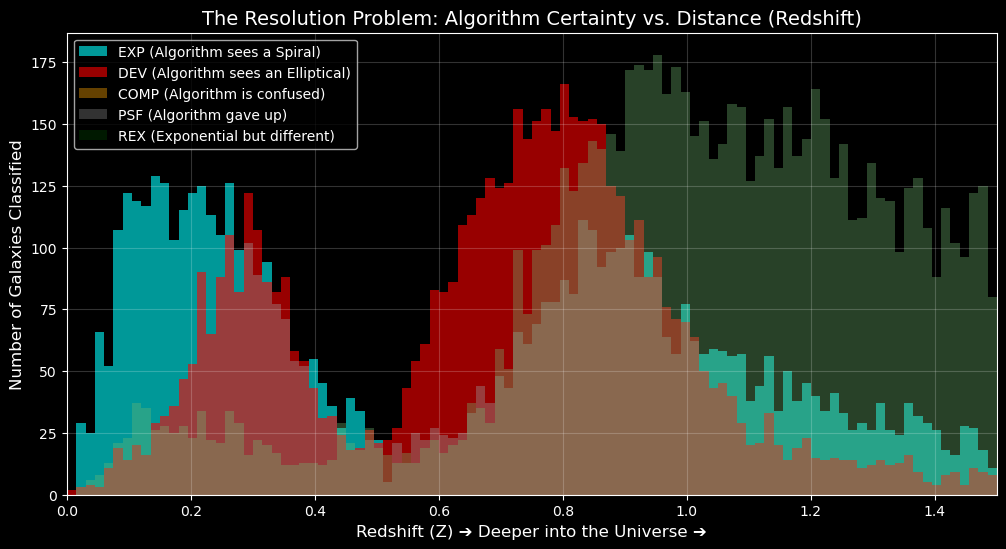

In [19]:
# Isolate the morphological classifications and distance (Z)
z_vals = catalog['Z']
morphs = catalog['MORPHTYPE'].astype(str) # Ensure it's a string

# Filter out the primary shapes
mask_exp = morphs == 'EXP'
mask_dev = morphs == 'DEV'
mask_comp = morphs == 'COMP' # "Composite" (The algorithm is guessing/unsure)
mask_psf = morphs == 'PSF'   # "Point Source" (The algorithm gave up and called it a star)

# Create a Histogram to show how the algorithm performs over distance
plt.style.use('dark_background')
plt.figure(figsize=(12, 6))

plt.hist(z_vals[mask_exp], bins=100, range=(0, 1.5), color='cyan', alpha=0.6, label='EXP (Algorithm sees a Spiral)')
plt.hist(z_vals[mask_dev], bins=100, range=(0, 1.5), color='red', alpha=0.6, label='DEV (Algorithm sees an Elliptical)')
plt.hist(z_vals[mask_comp], bins=100, range=(0, 1.5), color='orange', alpha=0.4, label='COMP (Algorithm is confused)')
plt.hist(z_vals[mask_psf], bins=100, range=(0, 1.5), color='white', alpha=0.2, label='PSF (Algorithm gave up)')
plt.hist(z_vals[mask_psf], bins=100, range=(0, 1.5), color='green', alpha=0.2, label='REX (Exponential but different)')


plt.title("The Resolution Problem: Algorithm Certainty vs. Distance (Redshift)", fontsize=14)
plt.xlabel("Redshift (Z) ➔ Deeper into the Universe ➔", fontsize=12)
plt.ylabel("Number of Galaxies Classified", fontsize=12)
plt.xlim(0, 1.5)
plt.legend()
plt.grid(alpha=0.2)
plt.show()

In [20]:
# Isolate only the objects where the algorithm made a confident shape guess
confident_mask = (catalog['MORPHTYPE'] == 'EXP') | (catalog['MORPHTYPE'] == 'DEV')

confident_shapes = catalog['MORPHTYPE'][confident_mask]
confident_subtypes = catalog['object_subtype'][confident_mask]

# Check how many algorithm EXP galaxies we correctly flagged as spiral (Subtype 1)
exp_mask = confident_shapes == 'EXP'
total_exp = np.sum(exp_mask)
matched_spirals = np.sum((confident_shapes == 'EXP') & (confident_subtypes == 1))

# Prevent division by zero just in case
spiral_accuracy = (matched_spirals / total_exp) * 100 if total_exp > 0 else 0

# Check how many algorithm DEV galaxies we correctly flagged as elliptical (Subtype 2)
dev_mask = confident_shapes == 'DEV'
total_dev = np.sum(dev_mask)
matched_ellipticals = np.sum((confident_shapes == 'DEV') & (confident_subtypes == 2))

elliptical_accuracy = (matched_ellipticals / total_dev) * 100 if total_dev > 0 else 0

# Print the final audit
print("=== Color vs. Morphology Scientific Audit ===")
print(f"Total confident shape classifications tested: {total_exp + total_dev:,}")
print("---------------------------------------------")
print(f"✅ Spiral (EXP) Match Rate:      {spiral_accuracy:.1f}%")
print(f"✅ Elliptical (DEV) Match Rate:  {elliptical_accuracy:.1f}%")
print("=============================================")

=== Color vs. Morphology Scientific Audit ===
Total confident shape classifications tested: 11,686
---------------------------------------------
✅ Spiral (EXP) Match Rate:      76.9%
✅ Elliptical (DEV) Match Rate:  64.2%
